# 第四章配套代码：A 股多因子选股策略综合案例

本 notebook 对应 `04_case_study.md`，实现从数据下载到策略报告的完整端到端流程。

**依赖库**：`baostock`, `pandas`, `numpy`, `scipy`, `statsmodels`, `matplotlib`, `seaborn`, `quantstats`

**运行顺序**：按节顺序从头到尾运行，每节输出供后续节使用。

## 第0节　全局设置与公共函数

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pearsonr, spearmanr

warnings.filterwarnings('ignore')

import matplotlib, platform
if platform.system() == 'Windows':
    matplotlib.rc('font', family='Microsoft YaHei')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='PingFang SC')
else:
    matplotlib.rc('font', family='WenQuanYi Micro Hei')
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['savefig.dpi'] = 150
matplotlib.rcParams['savefig.bbox'] = 'tight'

os.makedirs('data/stock', exist_ok=True)
os.makedirs('figs', exist_ok=True)

# ============================================================
# 全局参数（统一在此修改）
# ============================================================
TRADING_DAYS = 252
RF_ANNUAL    = 0.02
RF_DAILY     = RF_ANNUAL / TRADING_DAYS
FEES_ONEWAY  = 0.002      # 单边手续费 0.2%
TOP_K        = 4          # 持仓股票数
MOM_WIN      = 120        # 动量因子窗口（交易日）
VOL_WIN      = 60         # 低波动因子窗口（交易日）
TRAIN_END    = '2021-12-31'
VALID_END    = '2022-12-31'
# 测试集：VALID_END 之后至数据末尾

# 股票池
STOCKS = {
    '600036': {'bs_code': 'sh.600036', 'name': '招商银行',  'industry': '银行'},
    '601318': {'bs_code': 'sh.601318', 'name': '中国平安',  'industry': '保险'},
    '600519': {'bs_code': 'sh.600519', 'name': '贵州茅台',  'industry': '白酒'},
    '000858': {'bs_code': 'sz.000858', 'name': '五粮液',    'industry': '白酒'},
    '601633': {'bs_code': 'sh.601633', 'name': '长城汽车',  'industry': '汽车'},
    '002594': {'bs_code': 'sz.002594', 'name': '比亚迪',    'industry': '汽车'},
    '000063': {'bs_code': 'sz.000063', 'name': '中兴通讯',  'industry': '通讯'},
    '002415': {'bs_code': 'sz.002415', 'name': '海康威视',  'industry': '科技'},
    '600887': {'bs_code': 'sh.600887', 'name': '伊利股份',  'industry': '食品'},
    '603288': {'bs_code': 'sh.603288', 'name': '海天味业',  'industry': '食品'},
}
NAME2CODE = {v['name']: k for k, v in STOCKS.items()}
NAME2IND  = {v['name']: v['industry'] for v in STOCKS.values()}
IND_COLORS = {
    '银行': '#1f77b4', '保险': '#aec7e8',
    '白酒': '#d62728', '汽车': '#ff7f0e',
    '通讯': '#2ca02c', '科技': '#98df8a',
    '食品': '#9467bd',
}

# ============================================================
# 公共函数
# ============================================================
def calc_metrics(nav, benchmark_nav=None, rf=RF_ANNUAL, label='策略'):
    """从净值序列计算全套绩效指标，返回字典。"""
    ret = nav.pct_change().dropna()
    if len(ret) < 5:
        return {}
    ann_ret = ret.mean() * TRADING_DAYS
    ann_std = ret.std()  * np.sqrt(TRADING_DAYS)
    sharpe  = (ann_ret - rf) / ann_std if ann_std > 0 else np.nan
    neg     = ret[ret < RF_DAILY]
    dstd    = np.sqrt((neg**2).mean()) * np.sqrt(TRADING_DAYS) if len(neg) > 0 else ann_std
    sortino = (ann_ret - rf) / dstd if dstd > 0 else np.nan
    peak    = nav.cummax()
    mdd     = ((nav - peak) / peak).min()
    calmar  = ann_ret / abs(mdd) if mdd < 0 else np.nan
    var95   = -np.percentile(ret, 5)
    cvar95  = -ret[ret < -var95].mean() if (ret < -var95).any() else var95
    monthly = ret.resample('ME').apply(lambda x: (1+x).prod()-1)
    neg_pct = (monthly < 0).mean()

    m = {
        '年化收益(%)':  round(ann_ret*100, 2),
        '年化波动(%)':  round(ann_std*100, 2),
        '最大回撤(%)':  round(mdd*100, 2),
        '夏普比率':     round(sharpe, 3),
        '索提诺比率':   round(sortino, 3),
        '卡玛比率':     round(calmar, 3),
        '日CVaR95(%)':  round(cvar95*100, 3),
        '负月份占比':   f'{neg_pct:.1%}',
    }
    if benchmark_nav is not None:
        b_ret    = benchmark_nav.pct_change().dropna().reindex(ret.index).fillna(0)
        b_annret = b_ret.mean() * TRADING_DAYS
        exc      = ret - b_ret
        te       = exc.std() * np.sqrt(TRADING_DAYS)
        ir       = exc.mean() * TRADING_DAYS / te if te > 0 else np.nan
        cov_mat  = np.cov(ret.values, b_ret.values)
        beta     = cov_mat[0,1] / cov_mat[1,1] if cov_mat[1,1] > 0 else np.nan
        m.update({
            '年化超额(%)':  round((ann_ret - b_annret)*100, 2),
            '信息比率':     round(ir, 3),
            '跟踪误差(%)':  round(te*100, 2),
            'Beta':         round(beta, 3),
        })
    return m

def print_metrics_table(metrics_dict):
    """将多个策略的绩效指标打印为对比表。"""
    df = pd.DataFrame(metrics_dict)
    print(df.to_string())
    return df

print('全局设置完毕')

全局设置完毕


## 第1节　数据下载与质量检查

生成图：`fig_case_01_data_quality.png`

In [2]:
import baostock as bs
from datetime import datetime

lg = bs.login()
print('登录状态:', lg.error_msg)

START_DATE = '2020-01-01'
END_DATE   = datetime.today().strftime('%Y-%m-%d')

def download_stock(bs_code, start, end):
    """从 baostock 下载日线后复权数据，返回 DataFrame。"""
    rs = bs.query_history_k_data_plus(
        bs_code,
        'date,open,high,low,close,volume,amount',
        start_date=start, end_date=end,
        frequency='d', adjustflag='3'
    )
    rows = []
    while rs.error_code == '0' and rs.next():
        rows.append(rs.get_row_data())
    df = pd.DataFrame(rows, columns=rs.fields)
    for c in ['open','high','low','close','volume','amount']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df['date'] = pd.to_datetime(df['date'])
    return df.set_index('date').sort_index()

# 下载所有股票
for code, info in STOCKS.items():
    path = f'data/stock/stock_{code}.csv'
    if os.path.exists(path):
        print(f'{info["name"]}：已有数据，跳过')
        continue
    print(f'下载 {info["name"]}...')
    df = download_stock(info['bs_code'], START_DATE, END_DATE)
    df.index.name = '日期'
    df.rename(columns={'close':'收盘价','open':'开盘价','high':'最高价',
                        'low':'最低价','volume':'成交量','amount':'成交额'}, inplace=True)
    df.to_csv(path, encoding='utf-8-sig')

# 下载沪深300指数
idx_path = 'data/stock/index_000300.csv'
if not os.path.exists(idx_path):
    print('下载沪深300...')
    rs = bs.query_history_k_data_plus('sh.000300', 'date,close',
                                       start_date=START_DATE, end_date=END_DATE,
                                       frequency='d')
    rows = []
    while rs.error_code == '0' and rs.next():
        rows.append(rs.get_row_data())
    df_idx = pd.DataFrame(rows, columns=rs.fields)
    df_idx['close'] = pd.to_numeric(df_idx['close'], errors='coerce')
    df_idx['date']  = pd.to_datetime(df_idx['date'])
    df_idx = df_idx.set_index('date').rename(columns={'close':'收盘价'})
    df_idx.index.name = '日期'
    df_idx.to_csv(idx_path, encoding='utf-8-sig')

bs.logout()
print('\n数据下载完毕')

login success!
登录状态: success
招商银行：已有数据，跳过
下载 中国平安...
下载 贵州茅台...
下载 五粮液...
长城汽车：已有数据，跳过
下载 比亚迪...
中兴通讯：已有数据，跳过
下载 海康威视...
下载 伊利股份...
下载 海天味业...
logout success!

数据下载完毕


In [3]:
# ------------------------------------------------------------------
# 质量检查与价格矩阵构建
# ------------------------------------------------------------------
price_dict   = {}   # 各股票收盘价 Series
quality_info = []   # 质量检查记录

for code, info in STOCKS.items():
    df = pd.read_csv(f'data/stock/stock_{code}.csv',
                     parse_dates=['日期']).set_index('日期').sort_index()
    price = df['收盘价'].replace(0, np.nan)  # 停牌=0时标为NaN
    price_dict[info['name']] = price

    ret = np.log(price / price.shift(1)).dropna()
    extreme = ret[ret.abs() > 0.20]   # ±20% 以上视为极端值
    quality_info.append({
        '股票':         info['name'],
        '行业':         info['industry'],
        '数据行数':     len(price),
        '起始日期':     str(price.index[0].date()),
        '结束日期':     str(price.index[-1].date()),
        '缺失值数量':   int(price.isna().sum()),
        '最大单日涨幅': f'{ret.max()*100:.1f}%',
        '最大单日跌幅': f'{ret.min()*100:.1f}%',
        '极端值次数(>20%)': len(extreme),
    })

quality_df = pd.DataFrame(quality_info).set_index('股票')
print('=== 数据质量检查汇总 ===')
print(quality_df.to_string())

# 对齐到公共交易日（取交集）
price_matrix = pd.DataFrame(price_dict).dropna()
print(f'\n公共交易日：{len(price_matrix)} 天（{price_matrix.index[0].date()} — {price_matrix.index[-1].date()}）')
price_matrix.to_csv('data/price_matrix.csv', encoding='utf-8-sig')
print('价格矩阵已保存：data/price_matrix.csv')

=== 数据质量检查汇总 ===
      行业  数据行数        起始日期        结束日期  缺失值数量 最大单日涨幅   最大单日跌幅  极端值次数(>20%)
股票                                                                        
招商银行  银行  1515  2020-01-02  2026-04-07      0   9.5%    -9.0%            0
中国平安  保险  1516  2020-01-02  2026-04-08      0   9.5%   -10.3%            0
贵州茅台  白酒  1516  2020-01-02  2026-04-08      0   9.1%    -8.2%            0
五粮液   白酒  1516  2020-01-02  2026-04-08      0   9.5%   -10.5%            0
长城汽车  汽车  1515  2020-01-02  2026-04-07      0   9.6%   -10.5%            0
比亚迪   汽车  1516  2020-01-02  2026-04-08      0   9.5%  -110.7%            1
中兴通讯  通讯  1515  2020-01-02  2026-04-07      0   9.5%   -10.5%            0
海康威视  科技  1516  2020-01-02  2026-04-08      0   9.5%   -10.5%            0
伊利股份  食品  1516  2020-01-02  2026-04-08      0   9.5%   -10.6%            0
海天味业  食品  1516  2020-01-02  2026-04-08      0   9.5%   -24.1%            1

公共交易日：1515 天（2020-01-02 — 2026-04-07）
价格矩阵已保存：data/price_matrix.csv


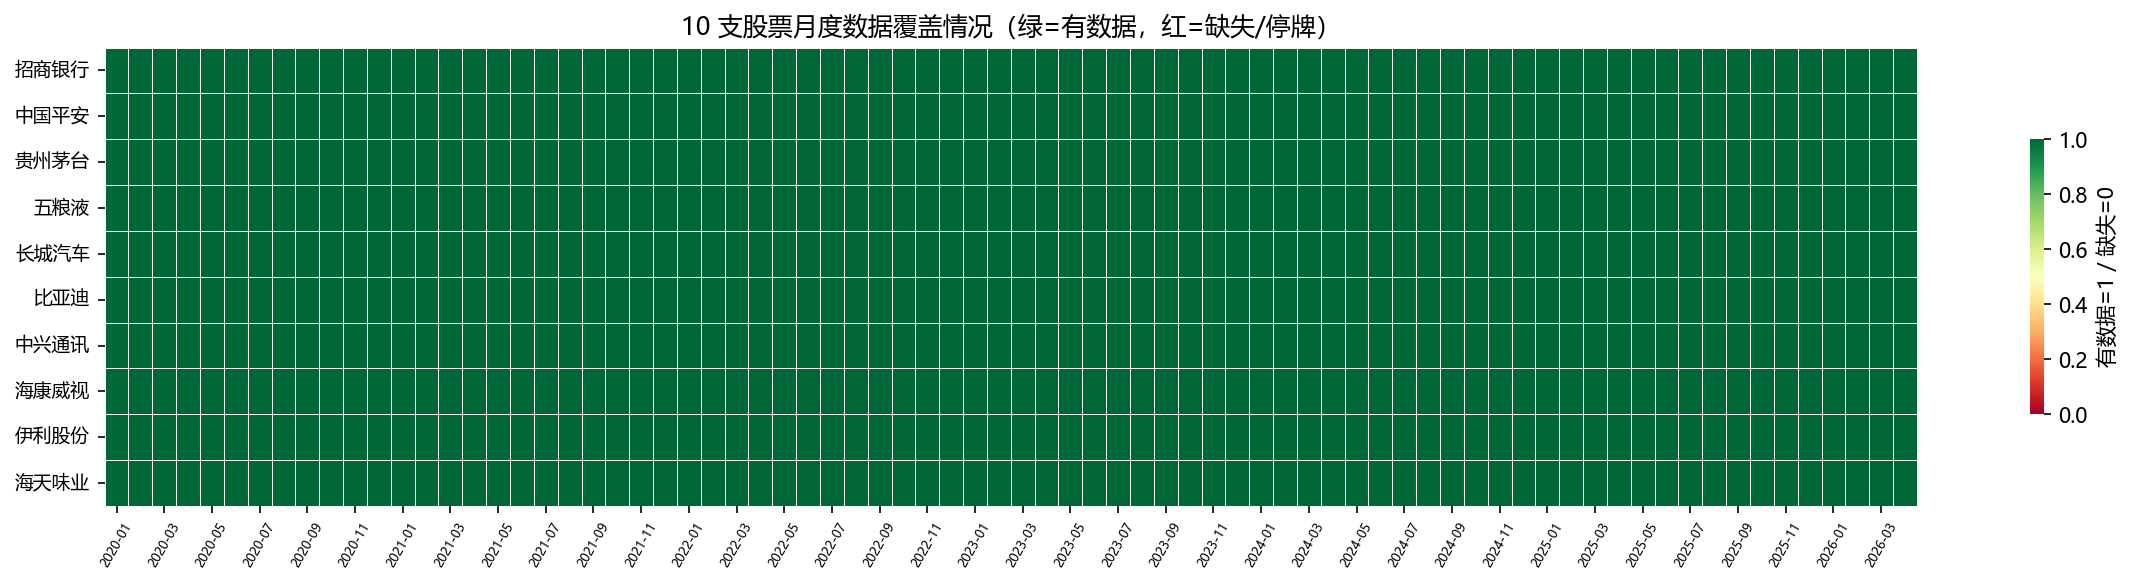

图片已保存：./figs/fig_case_01_data_quality.png


In [4]:
# 绘制数据覆盖热力图
coverage_data = {}
for code, info in STOCKS.items():
    df = pd.read_csv(f'data/stock/stock_{code}.csv',
                     parse_dates=['日期']).set_index('日期')
    monthly = df['收盘价'].resample('ME').count()
    coverage_data[info['name']] = (monthly > 0).astype(int)

coverage_df = pd.DataFrame(coverage_data).T
coverage_df.columns = [str(d)[:7] for d in coverage_df.columns]

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(coverage_df, cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': '有数据=1 / 缺失=0', 'shrink': 0.6},
            ax=ax)
ax.set_title('10 支股票月度数据覆盖情况（绿=有数据，红=缺失/停牌）', fontsize=12)
ax.set_xlabel('')
plt.xticks(fontsize=6, rotation=60)
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.savefig('./figs/fig_case_01_data_quality.png')
plt.show()
print('图片已保存：./figs/fig_case_01_data_quality.png')

## 第1节（续）　探索性分析

生成图：`fig_case_02_eda.png`

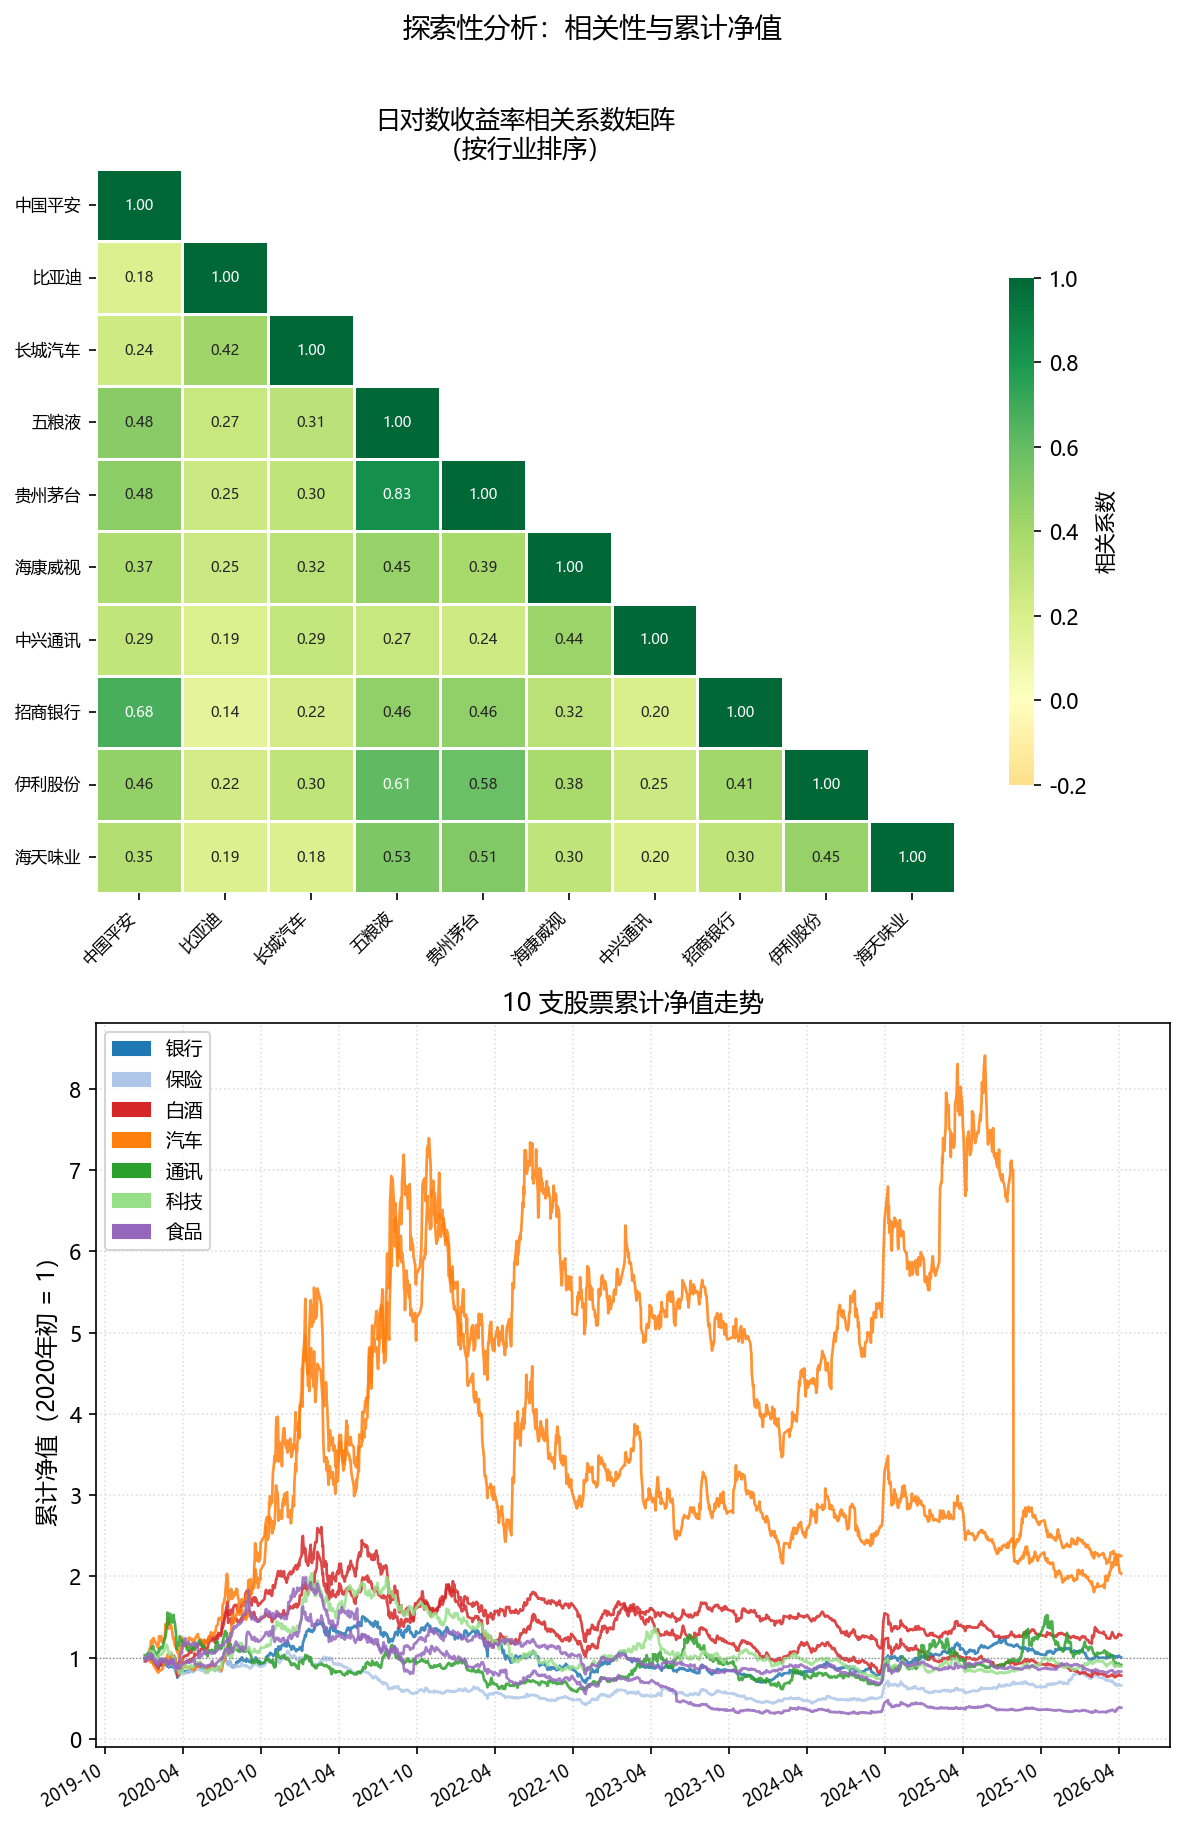

图片已保存：./figs/fig_case_02_eda.png


In [9]:
price_matrix = pd.read_csv('data/price_matrix.csv', parse_dates=['日期']).set_index('日期')
ret_matrix   = np.log(price_matrix / price_matrix.shift(1)).dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 12))

# 左图：相关系数热力图（对数收益率）
corr = ret_matrix.corr()
# 按行业排序
order = sorted(corr.columns, key=lambda x: (NAME2IND.get(x,''), x))
corr  = corr.loc[order, order]
mask  = np.triu(np.ones_like(corr), k=1)  # 只显示下三角
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-0.2, vmax=1.0,
            mask=mask, linewidths=0.5,
            annot_kws={'size': 7}, ax=ax1,
            cbar_kws={'label': '相关系数', 'shrink': 0.7})
ax1.set_title('日对数收益率相关系数矩阵\n（按行业排序）', fontsize=12)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(ax1.yaxis.get_majorticklabels(), fontsize=8)

# 右图：累计净值（按行业颜色）
nav_matrix = np.exp(ret_matrix.cumsum())
for col in nav_matrix.columns:
    ind   = NAME2IND.get(col, '其他')
    color = IND_COLORS.get(ind, '#333')
    ax2.plot(nav_matrix.index, nav_matrix[col],
             color=color, lw=1.3, alpha=0.85, label=col)

ax2.axhline(1, color='gray', lw=0.6, ls=':')
ax2.set_ylabel('累计净值（2020年初 = 1）', fontsize=11)
ax2.set_title('10 支股票累计净值走势', fontsize=12)
# 图例：按行业分组
handles = [mpatches.Patch(color=c, label=ind)
           for ind, c in IND_COLORS.items() if ind in NAME2IND.values()]
ax2.legend(handles=handles, fontsize=9, loc='upper left')
ax2.grid(linestyle=':', alpha=0.4)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

plt.suptitle('探索性分析：相关性与累计净值', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('./figs/fig_case_02_eda.png')
plt.show()
print('图片已保存：./figs/fig_case_02_eda.png')

## 第2节　三因子计算与综合打分

生成图：`fig_case_03_factors.png`

In [10]:
from scipy.stats.mstats import winsorize

def zscore_winsorize(series, limits=(0.05, 0.05)):
    """去极值（Winsorize）后进行 Z-score 标准化。"""
    ws = pd.Series(winsorize(series.dropna(), limits=limits),
                   index=series.dropna().index)
    ws = ws.reindex(series.index)
    return (ws - ws.mean()) / (ws.std() + 1e-8)

# 月末截面日期列表
month_ends = ret_matrix.resample('ME').last().index

factor_records = []   # 每月末每支股票的因子值记录

for dt in month_ends:
    idx = ret_matrix.index.get_indexer([dt], method='ffill')[0]
    if idx < max(MOM_WIN, VOL_WIN):
        continue

    row = {'日期': dt}
    for name in price_matrix.columns:
        r = ret_matrix[name]
        p = price_matrix[name]

        # 因子1：动量（过去 MOM_WIN 日累计对数收益率）
        row[f'{name}_mom'] = r.iloc[idx - MOM_WIN: idx].sum()
        # 因子2：低波动（过去 VOL_WIN 日年化标准差，取负）
        row[f'{name}_vol'] = -r.iloc[idx - VOL_WIN: idx].std() * np.sqrt(TRADING_DAYS)
        # 因子3：价值代理（收盘价负对数，价格越低得分越高）
        # 注：实际应替换为真实 P/B，见习题二
        row[f'{name}_val'] = -np.log(p.iloc[idx])

    factor_records.append(row)

factor_df = pd.DataFrame(factor_records).set_index('日期')
print(f'因子计算完毕：{len(factor_df)} 个月末截面')

# 截面标准化与等权合成综合得分
score_records = []
names = list(price_matrix.columns)

for dt in factor_df.index:
    row_scores = {'日期': dt}
    for name in names:
        m_raw = factor_df.loc[dt, f'{name}_mom']
        v_raw = factor_df.loc[dt, f'{name}_vol']
        val_raw = factor_df.loc[dt, f'{name}_val']
        row_scores[f'{name}_mom_raw']  = m_raw
        row_scores[f'{name}_vol_raw']  = v_raw
        row_scores[f'{name}_val_raw']  = val_raw

    # 截面 Z-score 标准化（对所有股票同时进行）
    mom_series = pd.Series({n: factor_df.loc[dt, f'{n}_mom'] for n in names})
    vol_series = pd.Series({n: factor_df.loc[dt, f'{n}_vol'] for n in names})
    val_series = pd.Series({n: factor_df.loc[dt, f'{n}_val'] for n in names})

    mom_z = zscore_winsorize(mom_series)
    vol_z = zscore_winsorize(vol_series)
    val_z = zscore_winsorize(val_series)

    for name in names:
        row_scores[f'{name}_mom_z']  = mom_z.get(name, np.nan)
        row_scores[f'{name}_vol_z']  = vol_z.get(name, np.nan)
        row_scores[f'{name}_val_z']  = val_z.get(name, np.nan)
        # 等权综合得分
        row_scores[f'{name}_score']  = np.nanmean([
            mom_z.get(name, np.nan),
            vol_z.get(name, np.nan),
            val_z.get(name, np.nan)
        ])
    score_records.append(row_scores)

score_df = pd.DataFrame(score_records).set_index('日期')

# 提取综合得分矩阵（行=日期，列=股票）
score_matrix = pd.DataFrame({
    name: score_df[f'{name}_score'] for name in names
})
score_matrix.to_csv('data/factor_scores.csv', encoding='utf-8-sig')
print('综合得分矩阵已保存：data/factor_scores.csv')

# 打印最近 6 个月末打分表
print('\n=== 最近6个月末综合得分与排名 ===')
for dt in score_matrix.index[-6:]:
    scores = score_matrix.loc[dt].sort_values(ascending=False)
    top    = scores.index[:TOP_K].tolist()
    print(f'{str(dt)[:7]}  TOP{TOP_K}：{"、".join(top)}')
    for name, val in scores.items():
        marker = '★' if name in top else '  '
        print(f'  {marker}{name:8s} {val:+.3f}')

因子计算完毕：70 个月末截面
综合得分矩阵已保存：data/factor_scores.csv

=== 最近6个月末综合得分与排名 ===
2025-11  TOP4：长城汽车、伊利股份、海天味业、中国平安
  ★长城汽车     +0.452
  ★伊利股份     +0.432
  ★海天味业     +0.317
  ★中国平安     +0.307
    招商银行     +0.305
    海康威视     +0.257
    五粮液      +0.066
    中兴通讯     -0.472
    贵州茅台     -0.584
    比亚迪      -1.081
2025-12  TOP4：伊利股份、海天味业、长城汽车、海康威视
  ★伊利股份     +0.528
  ★海天味业     +0.451
  ★长城汽车     +0.434
  ★海康威视     +0.282
    招商银行     +0.237
    中国平安     +0.184
    五粮液      +0.021
    中兴通讯     -0.532
    贵州茅台     -0.566
    比亚迪      -1.038
2026-01  TOP4：海康威视、伊利股份、长城汽车、海天味业
  ★海康威视     +0.614
  ★伊利股份     +0.396
  ★长城汽车     +0.359
  ★海天味业     +0.317
    中国平安     +0.179
    招商银行     -0.042
    中兴通讯     -0.218
    比亚迪      -0.385
    五粮液      -0.471
    贵州茅台     -0.749
2026-02  TOP4：伊利股份、海康威视、招商银行、海天味业
  ★伊利股份     +0.719
  ★海康威视     +0.673
  ★招商银行     +0.364
  ★海天味业     +0.283
    长城汽车     +0.211
    中国平安     +0.206
    比亚迪      -0.374
    五粮液      -0.573
    贵州茅台     -0.590
    中兴通讯     -0.919
2026-03 

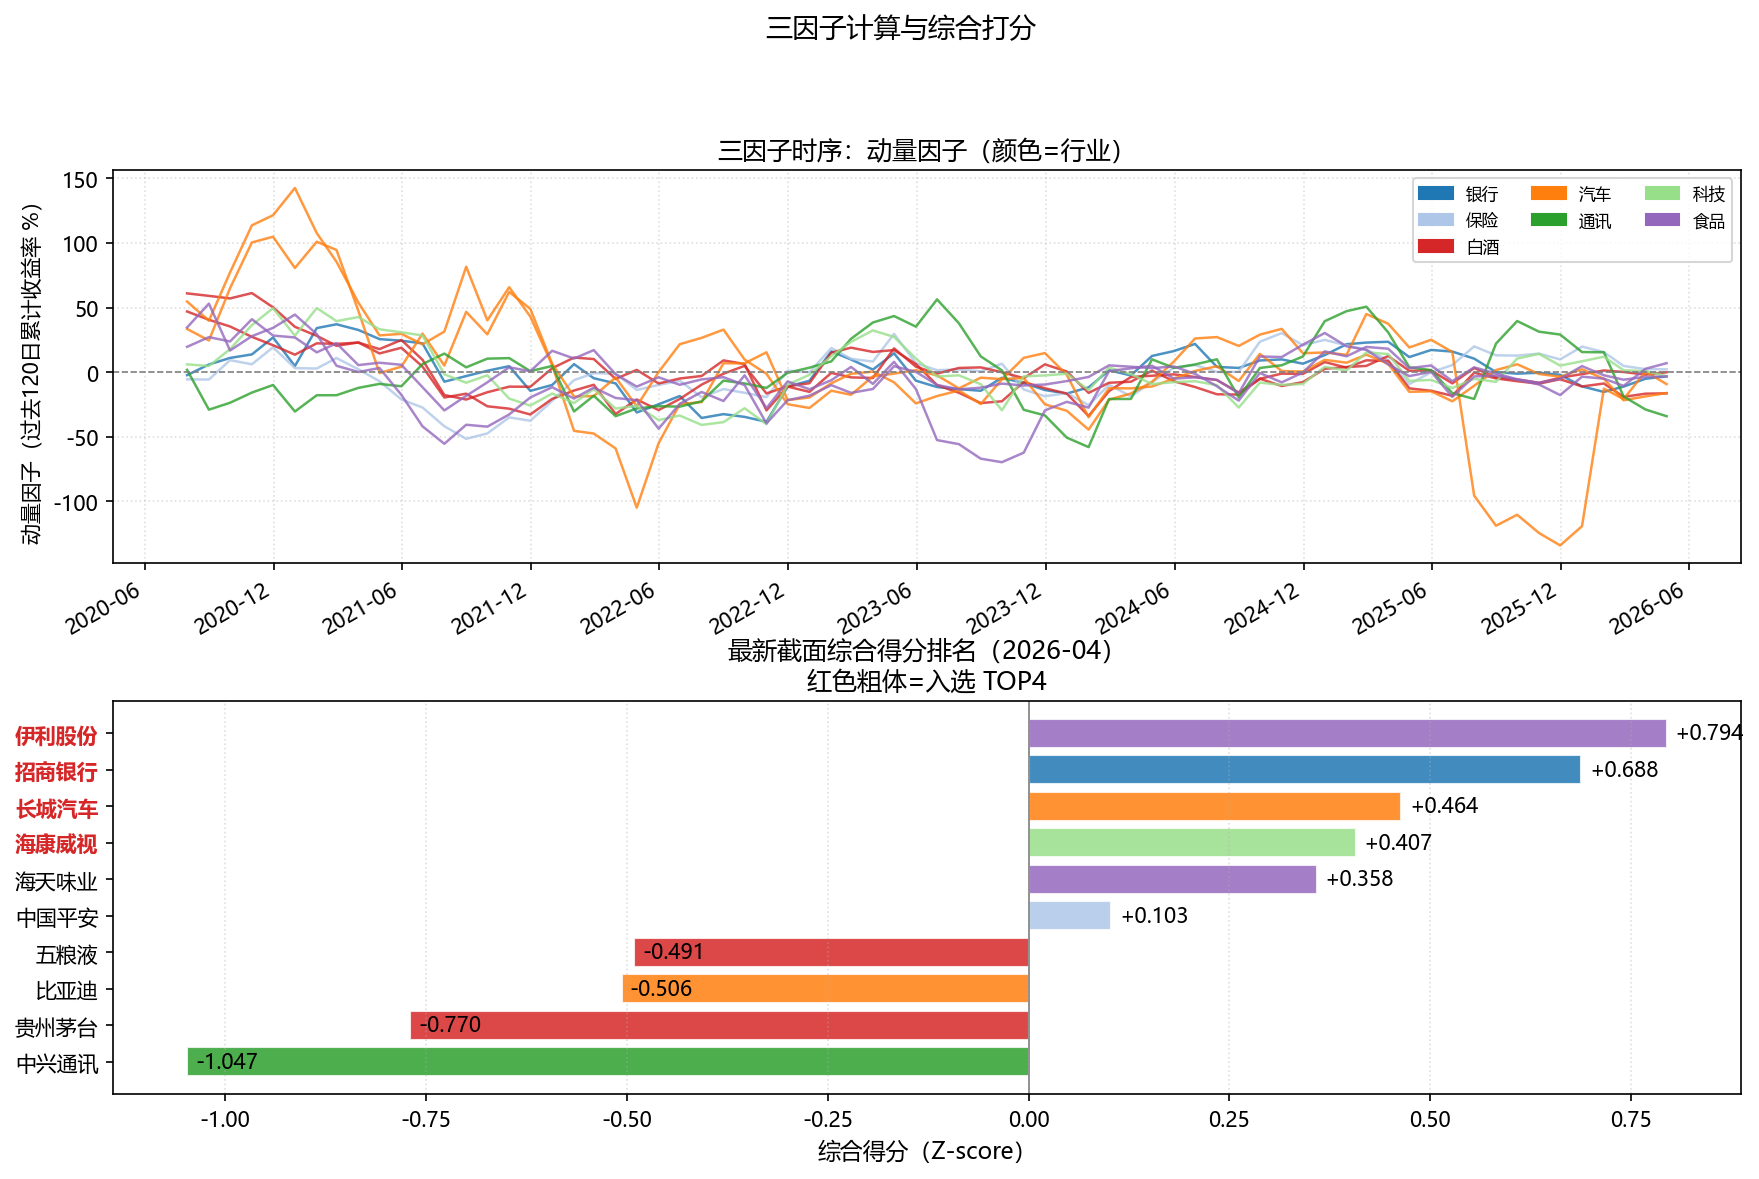

图片已保存：./figs/fig_case_03_factors.png


In [17]:
# 绘制因子时序与最新截面得分
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
fig.subplots_adjust(hspace=0.35)

# 子图1：动量因子时序（10条线，按行业颜色）
for name in names:
    ind   = NAME2IND.get(name, '其他')
    color = IND_COLORS.get(ind, '#999')
    mom_ts = pd.Series(
        {dt: score_df.loc[dt, f'{name}_mom_raw'] for dt in score_df.index}
    ) * 100
    ax1.plot(mom_ts, color=color, lw=1.2, alpha=0.8, label=name)

ax1.axhline(0, color='gray', lw=0.8, ls='--')
ax1.set_ylabel('动量因子（过去120日累计收益率 %）', fontsize=10)
ax1.set_title('三因子时序：动量因子（颜色=行业）', fontsize=12)
# 图例只展示行业颜色块
handles = [mpatches.Patch(color=c, label=ind)
           for ind, c in IND_COLORS.items() if ind in NAME2IND.values()]
ax1.legend(handles=handles, fontsize=8, loc='upper right', ncol=3)
ax1.grid(linestyle=':', alpha=0.4)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=10)

# 子图2：最新截面综合得分横向柱状图
latest_dt     = score_matrix.index[-1]
latest_scores = score_matrix.loc[latest_dt].sort_values(ascending=True)
bar_colors    = [IND_COLORS.get(NAME2IND.get(n,''), '#999')
                 for n in latest_scores.index]
bars = ax2.barh(range(len(latest_scores)), latest_scores.values,
                color=bar_colors, alpha=0.85, edgecolor='white')
ax2.set_yticks(range(len(latest_scores)))
ax2.set_yticklabels(latest_scores.index, fontsize=10)
ax2.axvline(0, color='gray', lw=0.8)

# 标注前 TOP_K 名
top_names = score_matrix.loc[latest_dt].nlargest(TOP_K).index
for i, name in enumerate(latest_scores.index):
    if name in top_names:
        ax2.get_yticklabels()[i].set_color('#d62728')
        ax2.get_yticklabels()[i].set_fontweight('bold')

for bar, val in zip(bars, latest_scores.values):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:+.3f}', va='center', fontsize=10)

ax2.set_xlabel('综合得分（Z-score）', fontsize=11)
ax2.set_title(f'最新截面综合得分排名（{str(latest_dt)[:7]}）\n红色粗体=入选 TOP{TOP_K}',
              fontsize=12)
ax2.grid(axis='x', linestyle=':', alpha=0.4)

plt.suptitle('三因子计算与综合打分', fontsize=13, y=1.01)
plt.savefig('./figs/fig_case_03_factors.png', bbox_inches='tight')
plt.show()
print('图片已保存：./figs/fig_case_03_factors.png')

## 第2节（续）　持仓矩阵与换手率

生成图：`fig_case_04_holdings.png`

平均月度换手率：20.0%
最大月度换手率：75.0%
月均手续费成本：0.080%（双边）


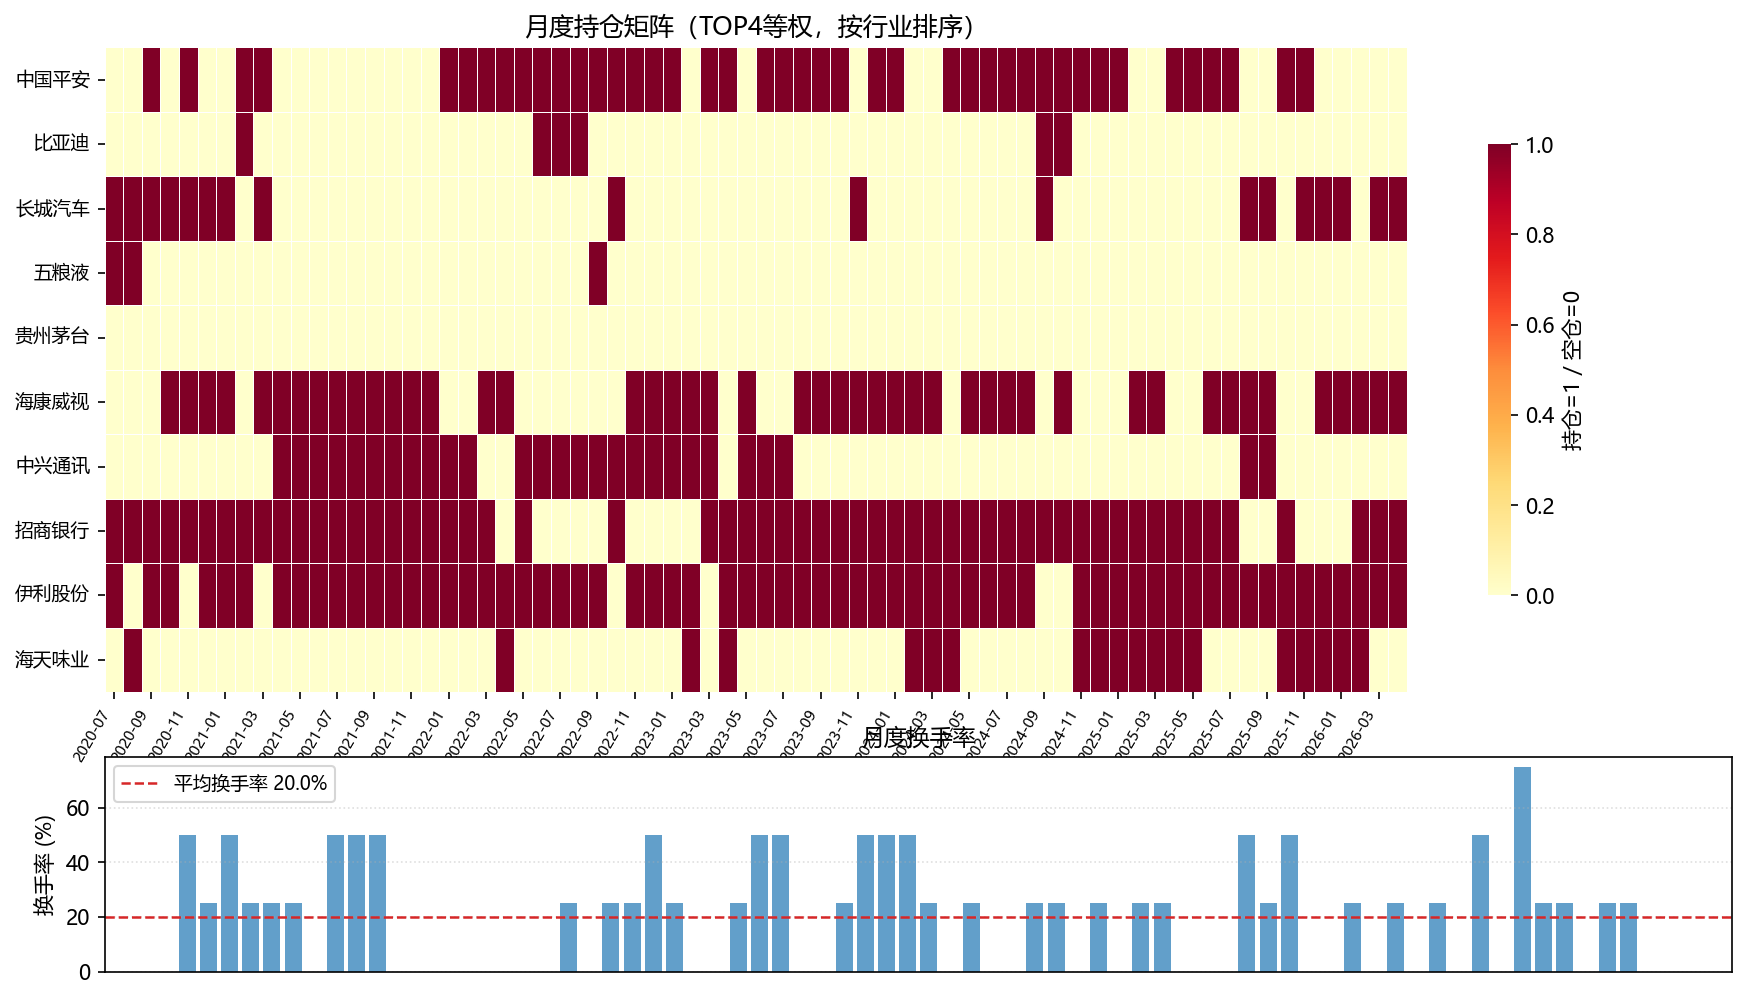

图片已保存：./figs/fig_case_04_holdings.png


In [18]:
# 生成持仓权重矩阵（行=月末，列=股票，值=权重）
weight_matrix = pd.DataFrame(0.0, index=score_matrix.index, columns=names)

for dt in score_matrix.index:
    top_k = score_matrix.loc[dt].nlargest(TOP_K).index
    weight_matrix.loc[dt, top_k] = 1.0 / TOP_K

# 计算月度换手率
turnover = weight_matrix.diff().abs().sum(axis=1) / 2
turnover.iloc[0] = weight_matrix.iloc[0].sum() / 2  # 第一期建仓

print(f'平均月度换手率：{turnover.mean():.1%}')
print(f'最大月度换手率：{turnover.max():.1%}')
print(f'月均手续费成本：{turnover.mean() * FEES_ONEWAY * 2 * 100:.3f}%（双边）')

# 绘图：持仓热力图 + 换手率
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8),
                                gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0.15)

# 持仓热力图（1=持仓，0=不持仓）
holdings_binary = (weight_matrix > 0).astype(int)
# 为热力图添加行业颜色，用自定义颜色映射
ind_order = sorted(names, key=lambda x: (NAME2IND.get(x,''), x))
hm_data   = holdings_binary[ind_order].T
hm_data.columns = [str(d)[:7] for d in hm_data.columns]

sns.heatmap(hm_data, cmap='YlOrRd', vmin=0, vmax=1,
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': '持仓=1 / 空仓=0', 'shrink': 0.7},
            ax=ax1)
ax1.set_title(f'月度持仓矩阵（TOP{TOP_K}等权，按行业排序）', fontsize=12)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=60, ha='right', fontsize=7)
plt.setp(ax1.yaxis.get_majorticklabels(), fontsize=9)

# 换手率柱状图
ax2.bar(range(len(turnover)), turnover.values * 100,
        color='#1f77b4', alpha=0.7, width=0.8)
ax2.axhline(turnover.mean() * 100, color='#d62728', lw=1.2, ls='--',
            label=f'平均换手率 {turnover.mean()*100:.1f}%')
ax2.set_ylabel('换手率 (%)', fontsize=10)
ax2.set_xticks([])
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle=':', alpha=0.4)
ax2.set_title('月度换手率', fontsize=11)

plt.savefig('./figs/fig_case_04_holdings.png')
plt.show()
print('图片已保存：./figs/fig_case_04_holdings.png')

## 第3节　策略回测与绩效评价

生成图：`fig_case_05_nav.png`、`fig_case_06_walkforward.png`、`fig_case_07_monthly_heatmap.png`

In [19]:
# ------------------------------------------------------------------
# 月频多因子策略回测（日频净值）
# ------------------------------------------------------------------
ret_matrix = np.log(price_matrix / price_matrix.shift(1)).dropna()

# 将月末权重扩展到日频（用前向填充：当月用上月末权重）
# 注意：month_end 的权重在该月末后第一个交易日才生效（shift 1天）
daily_weights = weight_matrix.reindex(ret_matrix.index, method='ffill').shift(1).fillna(0)

# 每日组合收益率 = 权重 × 各股票日收益率（对数近似=简单）
# 使用简单收益率更准确（权重是基于价格比例的）
simple_ret = price_matrix.pct_change().dropna()
daily_weights_s = weight_matrix.reindex(simple_ret.index, method='ffill').shift(1).fillna(0)

# 月末调仓时扣除手续费：换手率 × 双边手续费
monthly_tc = (turnover * FEES_ONEWAY * 2).reindex(simple_ret.index, method='ffill')
# 只在调仓日（月末后第一个交易日）扣除，其余日=0
turnover_daily = pd.Series(0.0, index=simple_ret.index)
for dt in weight_matrix.index:
    # 找该月末之后的第一个交易日
    future_dates = simple_ret.index[simple_ret.index > dt]
    if len(future_dates) > 0:
        turnover_daily[future_dates[0]] = turnover[dt] * FEES_ONEWAY * 2

# 策略日收益率
port_ret = (daily_weights_s * simple_ret).sum(axis=1) - turnover_daily
nav_strat = (1 + port_ret).cumprod()

# 等权基准净值（10支股票，月度调仓，无手续费简化）
nav_ewgt  = (1 + simple_ret.mean(axis=1)).cumprod()

# 沪深300基准净值
df_idx    = pd.read_csv('data/stock/index_000300.csv',
                         parse_dates=['日期']).set_index('日期').sort_index()
price_idx = df_idx['收盘价']
nav_idx   = (price_idx / price_idx.reindex(nav_strat.index, method='ffill').iloc[0]).reindex(nav_strat.index, method='ffill')

print('回测完成，全样本绩效：')
m_all = calc_metrics(nav_strat, benchmark_nav=nav_idx, label='三因子策略')
for k,v in m_all.items():
    print(f'  {k}: {v}')

回测完成，全样本绩效：
  年化收益(%): 2.17
  年化波动(%): 21.67
  最大回撤(%): -53.93
  夏普比率: 0.008
  索提诺比率: 0.009
  卡玛比率: 0.04
  日CVaR95(%): 2.961
  负月份占比: 44.7%
  年化超额(%): -0.75
  信息比率: -0.049
  跟踪误差(%): 15.24
  Beta: 0.835



=== 全样本绩效对比 ===
            三因子策略   等权基准  沪深300
年化收益(%)      2.17   6.56   2.92
年化波动(%)     21.67  22.77  18.82
最大回撤(%)    -53.93 -47.05  -45.6
夏普比率        0.008    0.2  0.049
索提诺比率       0.009  0.209  0.049
卡玛比率         0.04  0.139  0.064
日CVaR95(%)  2.961  3.264  2.737
负月份占比       44.7%  56.6%  52.6%
年化超额(%)     -0.75   3.64    NaN
信息比率       -0.049  0.349    NaN
跟踪误差(%)     15.24  10.43    NaN
Beta        0.835  1.078    NaN


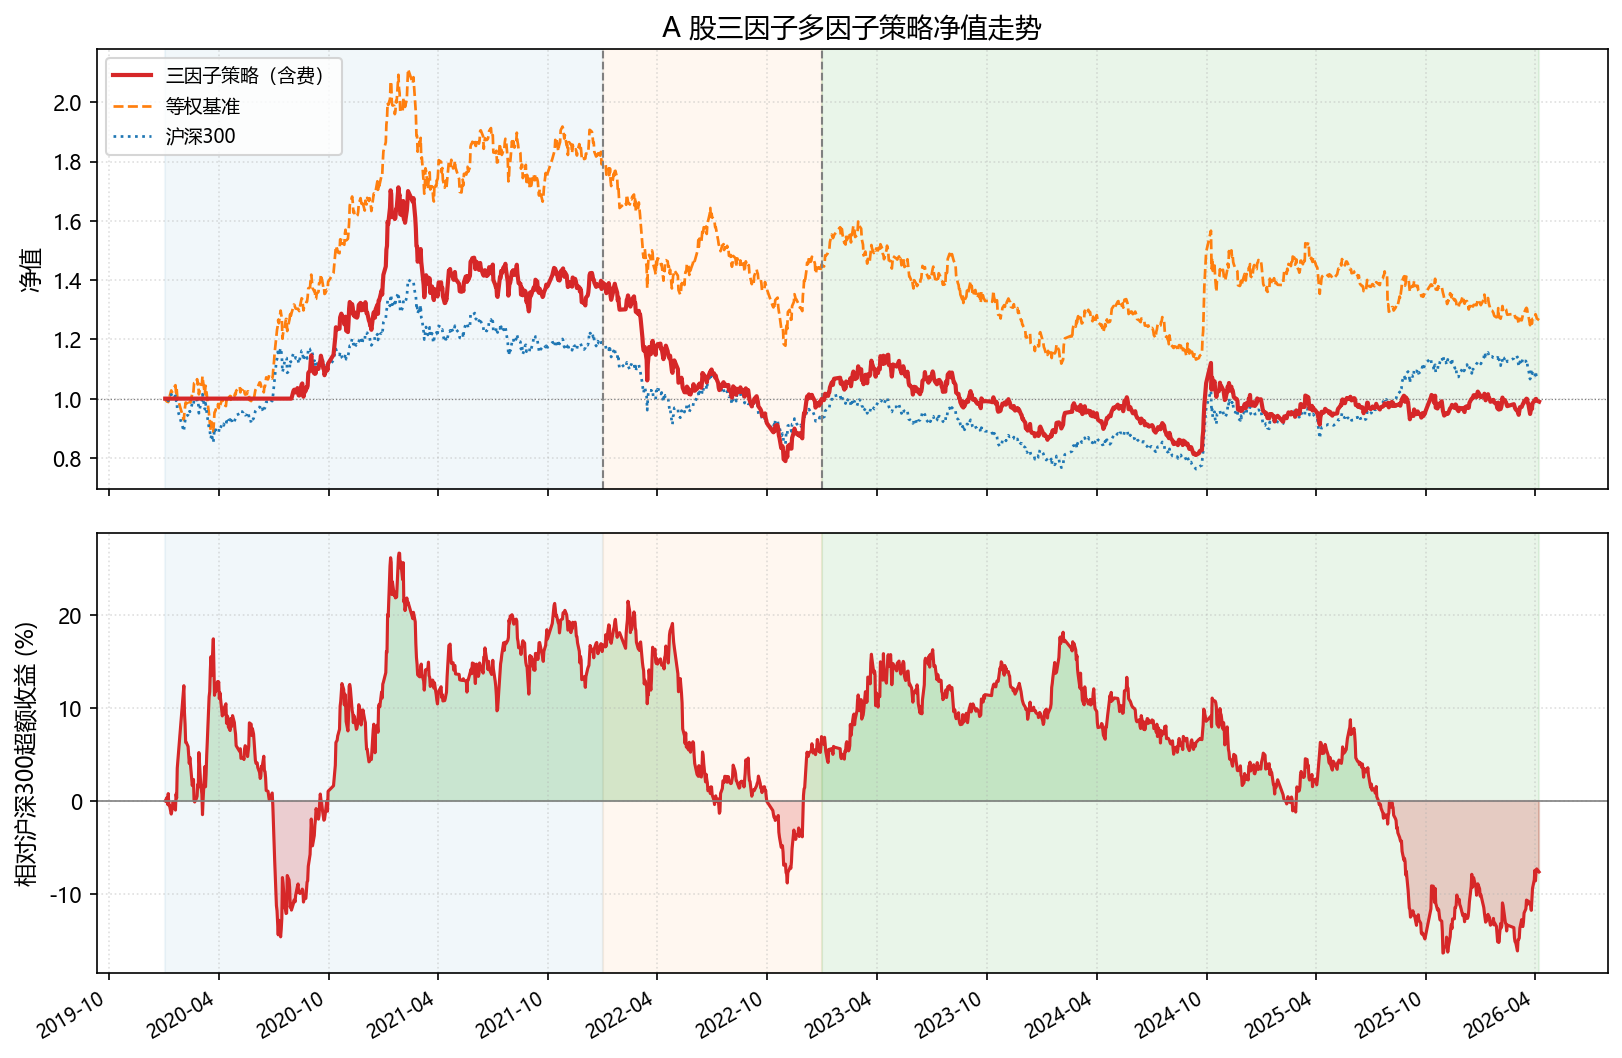

图片已保存：./figs/fig_case_05_nav.png


In [20]:
# 分段绩效对比表
def segment_metrics(nav, bm, label, start=None, end=None):
    n = nav[start:end] if start or end else nav
    b = bm[start:end]  if start or end else bm
    n = n / n.iloc[0]; b = b / b.iloc[0]
    return calc_metrics(n, b, label=label)

metrics_all = {
    '三因子策略':   calc_metrics(nav_strat, nav_idx),
    '等权基准':     calc_metrics(nav_ewgt,  nav_idx),
    '沪深300':      calc_metrics(nav_idx),
}
print('\n=== 全样本绩效对比 ===')
print_metrics_table(metrics_all)

# 绘图：净值走势
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.subplots_adjust(hspace=0.1)

# 色块标注三段
def add_segments(ax):
    td = pd.Timestamp(TRAIN_END)
    vd = pd.Timestamp(VALID_END)
    ax.axvspan(nav_strat.index[0], td, alpha=0.06, color='#1f77b4')
    ax.axvspan(td, vd, alpha=0.06, color='#ff7f0e')
    ax.axvspan(vd, nav_strat.index[-1], alpha=0.1, color='#2ca02c')

add_segments(ax1)
ax1.plot(nav_strat, color='#d62728', lw=2.0,  label='三因子策略（含费）', zorder=3)
ax1.plot(nav_ewgt,  color='#ff7f0e', lw=1.3,  label='等权基准', ls='--')
ax1.plot(nav_idx,   color='#1f77b4', lw=1.3,  label='沪深300', ls=':')
ax1.axhline(1, color='gray', lw=0.6, ls=':')

# 添加三段标注
ymin = ax1.get_ylim()[0]
for label_, dt, color_ in [('训练',TRAIN_END,'#1f77b4'),
                              ('验证',VALID_END,'#ff7f0e')]:
    ax1.axvline(pd.Timestamp(dt), color='gray', lw=1, ls='--')

ax1.set_ylabel('净值', fontsize=11)
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(linestyle=':', alpha=0.4)
ax1.set_title('A 股三因子多因子策略净值走势', fontsize=13)

# 相对沪深300的累计超额收益
add_segments(ax2)
excess = (nav_strat / nav_idx - 1) * 100
ax2.plot(excess, color='#d62728', lw=1.5)
ax2.fill_between(excess.index, excess, 0,
                 where=(excess >= 0), alpha=0.2, color='#2ca02c')
ax2.fill_between(excess.index, excess, 0,
                 where=(excess < 0),  alpha=0.2, color='#d62728')
ax2.axhline(0, color='gray', lw=0.8)
ax2.set_ylabel('相对沪深300超额收益 (%)', fontsize=11)
ax2.grid(linestyle=':', alpha=0.4)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right', fontsize=9)

plt.savefig('./figs/fig_case_05_nav.png')
plt.show()
print('图片已保存：./figs/fig_case_05_nav.png')

=== Walk-Forward 样本外绩效 ===
  样本外起始   样本外结束  OOS夏普 OOS区间收益
2022-07 2022-12 -0.240   -3.0%
2023-01 2023-06  0.134    1.0%
2023-07 2023-12 -2.655  -16.2%
2024-01 2024-06 -0.061   -0.1%
2024-07 2024-12  1.044   12.8%
2025-01 2025-06  0.688    4.8%
2025-07 2025-12  0.356    2.8%


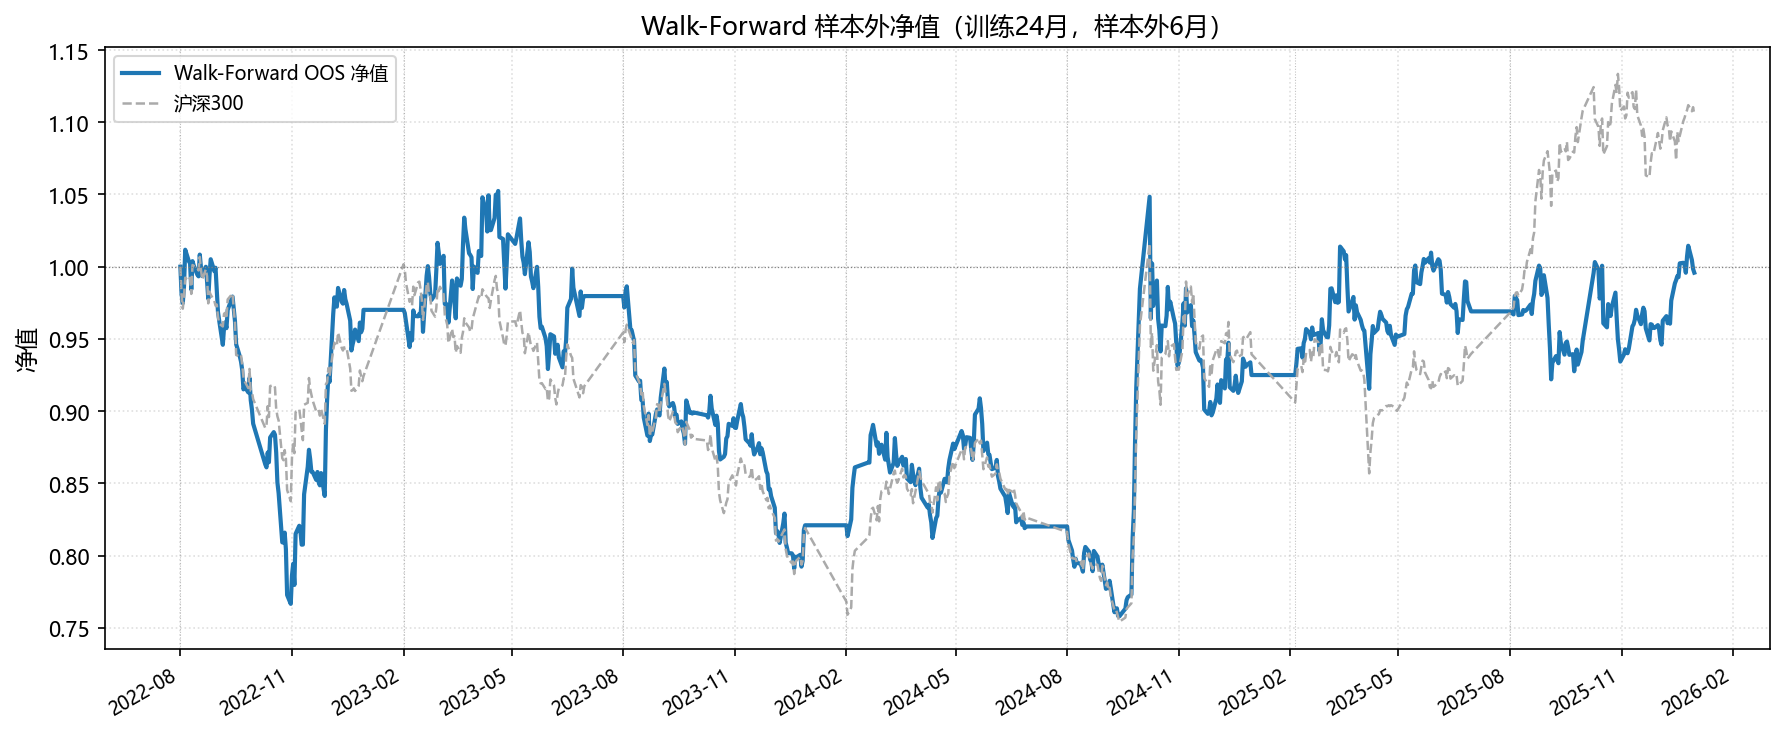

图片已保存：./figs/fig_case_06_walkforward.png


In [21]:
# Walk-Forward 检验（月频策略，训练24个月，样本外6个月）
# 月频策略因子权重固定（等权），WF 主要用于检验各期样本外表现稳定性
WF_TRAIN_MONTHS = 24
WF_OOS_MONTHS   = 6

month_index = score_matrix.index
wf_oos_navs = []
wf_records  = []

for start_i in range(WF_TRAIN_MONTHS, len(month_index) - WF_OOS_MONTHS + 1, WF_OOS_MONTHS):
    oos_months = month_index[start_i: start_i + WF_OOS_MONTHS]
    if len(oos_months) == 0:
        break

    # 样本外段的日期范围
    oos_start = oos_months[0]
    oos_end   = oos_months[-1]

    # 策略在该段的日度净值
    oos_dates = nav_strat.index[(nav_strat.index > oos_start) & (nav_strat.index <= oos_end)]
    if len(oos_dates) < 5:
        continue

    nav_seg = nav_strat[oos_dates] / nav_strat[oos_dates].iloc[0]
    bm_seg  = nav_idx[oos_dates]   / nav_idx[oos_dates].iloc[0]

    ret_seg = nav_seg.pct_change().dropna()
    sh = (ret_seg.mean()*TRADING_DAYS - RF_ANNUAL) / (ret_seg.std()*np.sqrt(TRADING_DAYS) + 1e-8)

    wf_oos_navs.append(nav_seg)
    wf_records.append({
        '样本外起始': str(oos_start)[:7],
        '样本外结束': str(oos_end)[:7],
        'OOS夏普':    round(sh, 3),
        'OOS区间收益': f'{(nav_seg.iloc[-1]-1)*100:.1f}%',
    })

wf_df = pd.DataFrame(wf_records)
print('=== Walk-Forward 样本外绩效 ===')
print(wf_df.to_string(index=False))

# 拼接样本外净值
cumulative = 1.0
combined_segs = []
for seg in wf_oos_navs:
    combined_segs.append(seg * cumulative)
    cumulative = (seg * cumulative).iloc[-1]
wf_nav_combined = pd.concat(combined_segs)

# 绘图
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(wf_nav_combined, color='#1f77b4', lw=2.0, label='Walk-Forward OOS 净值')
bnh_wf = nav_idx.reindex(wf_nav_combined.index, method='ffill')
bnh_wf = bnh_wf / bnh_wf.iloc[0]
ax.plot(bnh_wf, color='#aaa', lw=1.2, ls='--', label='沪深300')
ax.axhline(1, color='gray', lw=0.6, ls=':')

# 标注各个 OOS 窗口
for seg in wf_oos_navs:
    ax.axvline(seg.index[0], color='gray', lw=0.5, ls=':', alpha=0.5)

ax.set_ylabel('净值', fontsize=11)
ax.set_title(f'Walk-Forward 样本外净值（训练{WF_TRAIN_MONTHS}月，样本外{WF_OOS_MONTHS}月）', fontsize=12)
ax.legend(fontsize=9)
ax.grid(linestyle=':', alpha=0.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('./figs/fig_case_06_walkforward.png')
plt.show()
print('图片已保存：./figs/fig_case_06_walkforward.png')

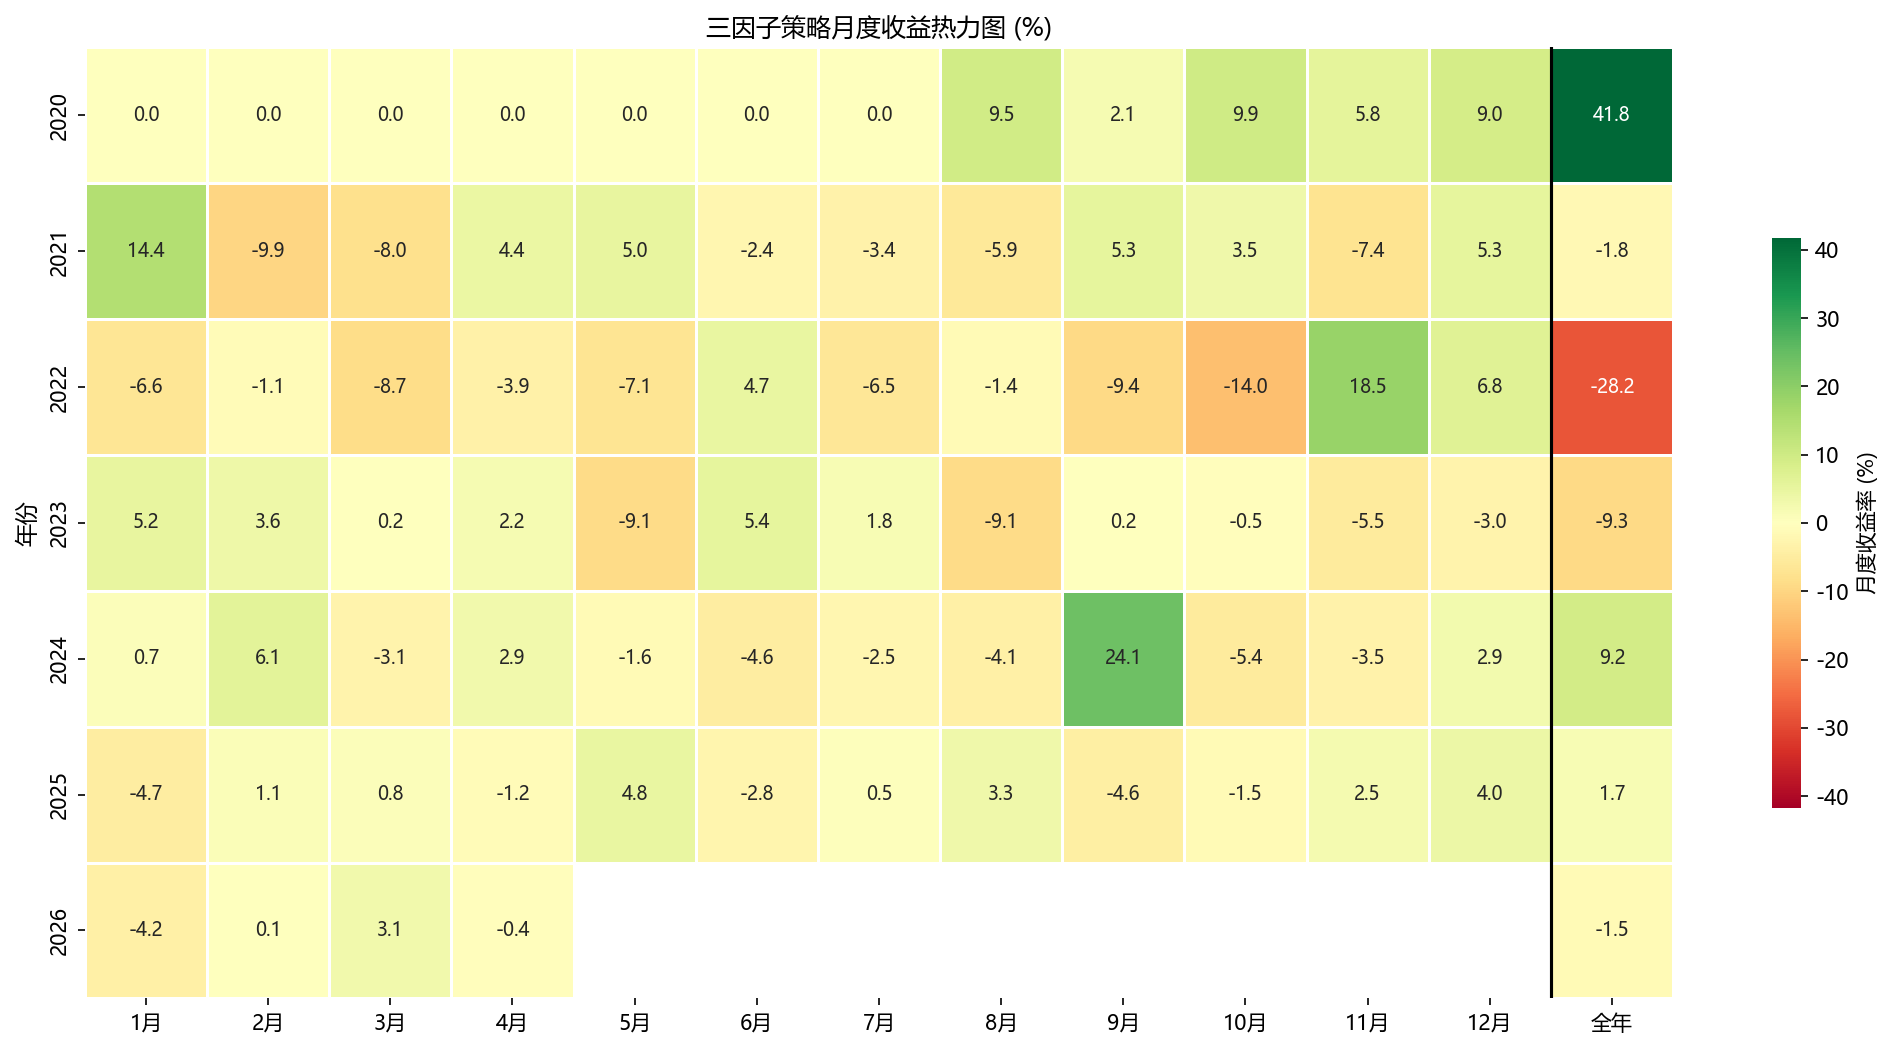

图片已保存：./figs/fig_case_07_monthly_heatmap.png


In [22]:
# 月度收益热力图
daily_ret_strat = nav_strat.pct_change().dropna()
monthly_ret     = daily_ret_strat.resample('ME').apply(lambda x: (1+x).prod()-1)
monthly_df      = monthly_ret.to_frame('收益率')
monthly_df['年份'] = monthly_df.index.year
monthly_df['月份'] = monthly_df.index.month
heat = monthly_df.pivot(index='年份', columns='月份', values='收益率') * 100

annual = daily_ret_strat.resample('YE').apply(lambda x: (1+x).prod()-1) * 100
annual.index = annual.index.year
heat['全年'] = annual
heat.columns = ['1月','2月','3月','4月','5月','6月',
                '7月','8月','9月','10月','11月','12月','全年'][:len(heat.columns)]

fig, ax = plt.subplots(figsize=(14, len(heat)*0.8 + 1.5))
vmax = max(abs(heat.values[np.isfinite(heat.values)]).max(), 1)
sns.heatmap(heat, annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, vmin=-vmax, vmax=vmax,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 9}, ax=ax,
            cbar_kws={'label': '月度收益率 (%)', 'shrink': 0.6})
ax.axvline(12, color='black', lw=1.5)
ax.set_title('三因子策略月度收益热力图 (%)', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('年份', fontsize=11)
plt.tight_layout()
plt.savefig('./figs/fig_case_07_monthly_heatmap.png')
plt.show()
print('图片已保存：./figs/fig_case_07_monthly_heatmap.png')

## 第4节　归因分析与因子分解

生成图：`fig_case_10_brinson.png`、`fig_case_11_factor_decomp.png`

In [23]:
# ------------------------------------------------------------------
# Brinson 行业归因
# ------------------------------------------------------------------
# 每月简单收益率矩阵
monthly_simple = price_matrix.resample('ME').last().pct_change().dropna()

brinson_rows = []
for dt in weight_matrix.index[1:]:  # 从第二个月开始，有上期权重
    if dt not in monthly_simple.index:
        continue
    month_ret = monthly_simple.loc[dt]  # 本月各股票收益率
    w_p = weight_matrix.loc[dt]         # 策略持仓权重
    # 等权基准：每支股票权重 = 1/10
    w_b = pd.Series(1.0 / len(names), index=names)

    R_p = (w_p * month_ret).sum()  # 策略月度收益
    R_b = (w_b * month_ret).sum()  # 等权基准月度收益

    # 按行业聚合
    industries = list(set(NAME2IND.values()))
    for ind in industries:
        ind_names = [n for n in names if NAME2IND[n] == ind]
        wp_ind = w_p[ind_names].sum()               # 策略行业权重
        wb_ind = w_b[ind_names].sum()               # 基准行业权重（= 2/10）
        rp_ind = month_ret[ind_names].mean()         # 行业内策略收益（等权）
        rb_ind = month_ret[ind_names].mean()         # 行业基准收益（同一批股票）

        AA = (wp_ind - wb_ind) * (rb_ind - R_b)     # 配置效应
        SS = wb_ind * (rp_ind - rb_ind)              # 选股效应（此处 rp=rb，SS≈0）
        IA = (wp_ind - wb_ind) * (rp_ind - rb_ind)  # 交互效应

        brinson_rows.append({'日期': dt, '行业': ind,
                              'AA': AA, 'SS': SS, 'IA': IA,
                              '合计': AA+SS+IA,
                              'R_策略': R_p, 'R_基准': R_b})

brinson_df = pd.DataFrame(brinson_rows)

# 按行业汇总（时间加权平均）
brinson_summary = brinson_df.groupby('行业')[['AA','SS','IA','合计']].sum() * 100
print('=== Brinson 行业归因（全样本累计，单位 %）===')
print(brinson_summary.round(2).to_string())
print(f'\n总配置效应：{brinson_summary["AA"].sum():.2f}%')
print(f'总选股效应：{brinson_summary["SS"].sum():.2f}%')
print(f'总交互效应：{brinson_summary["IA"].sum():.2f}%')

=== Brinson 行业归因（全样本累计，单位 %）===
       AA   SS   IA     合计
行业                        
保险  29.30  0.0  0.0  29.30
汽车  -1.59  0.0  0.0  -1.59
白酒   8.16  0.0  0.0   8.16
科技  13.07  0.0  0.0  13.07
通讯  16.93  0.0  0.0  16.93
银行   9.82  0.0  0.0   9.82
食品   1.29  0.0  0.0   1.29

总配置效应：76.98%
总选股效应：0.00%
总交互效应：0.00%


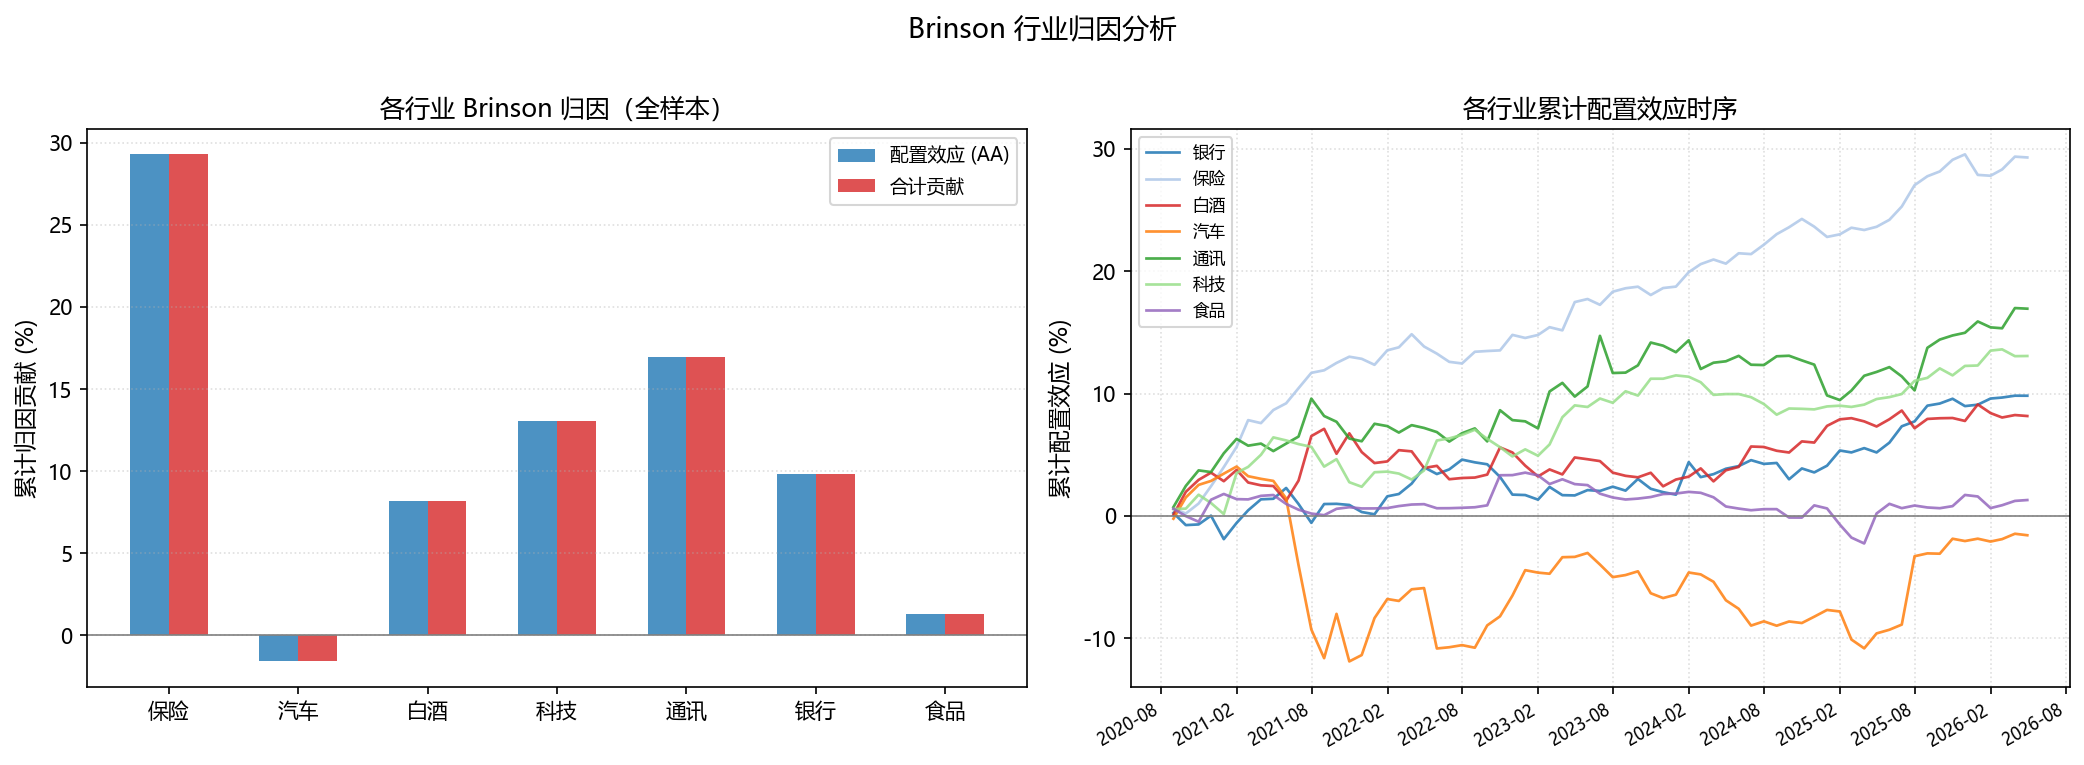

图片已保存：./figs/fig_case_10_brinson.png


In [24]:
# 绘图：Brinson 归因
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左图：各行业 AA/SS 柱状图
inds   = brinson_summary.index.tolist()
x      = np.arange(len(inds))
w_bar  = 0.3

ax1.bar(x - w_bar/2, brinson_summary['AA'].values,  w_bar,
        color='#1f77b4', alpha=0.8, label='配置效应 (AA)')
ax1.bar(x + w_bar/2, brinson_summary['合计'].values, w_bar,
        color='#d62728', alpha=0.8, label='合计贡献')
ax1.axhline(0, color='gray', lw=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(inds, fontsize=10)
ax1.set_ylabel('累计归因贡献 (%)', fontsize=11)
ax1.set_title('各行业 Brinson 归因（全样本）', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(axis='y', linestyle=':', alpha=0.4)

# 右图：AA/SS 的时序累积
for ind, color in IND_COLORS.items():
    subset = brinson_df[brinson_df['行业']==ind].set_index('日期')
    if len(subset) == 0:
        continue
    ax2.plot(subset.index, subset['AA'].cumsum()*100,
             color=color, lw=1.3, alpha=0.85, label=ind)

ax2.axhline(0, color='gray', lw=0.8)
ax2.set_ylabel('累计配置效应 (%)', fontsize=11)
ax2.set_title('各行业累计配置效应时序', fontsize=12)
ax2.legend(fontsize=8, loc='upper left')
ax2.grid(linestyle=':', alpha=0.4)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

plt.suptitle('Brinson 行业归因分析', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('./figs/fig_case_10_brinson.png')
plt.show()
print('图片已保存：./figs/fig_case_10_brinson.png')

=== 单因子 vs 三因子绩效对比 ===
           动量因子   低波动因子    价值代理   三因子组合    等权基准
年化收益(%)  -2.570   1.680  13.240   2.170   6.560
最大回撤(%) -63.710 -48.370 -33.020 -53.930 -47.050
夏普比率     -0.180  -0.015   0.497   0.008   0.200
卡玛比率     -0.040   0.035   0.401   0.040   0.139
信息比率     -0.289  -0.081   0.643  -0.049   0.349


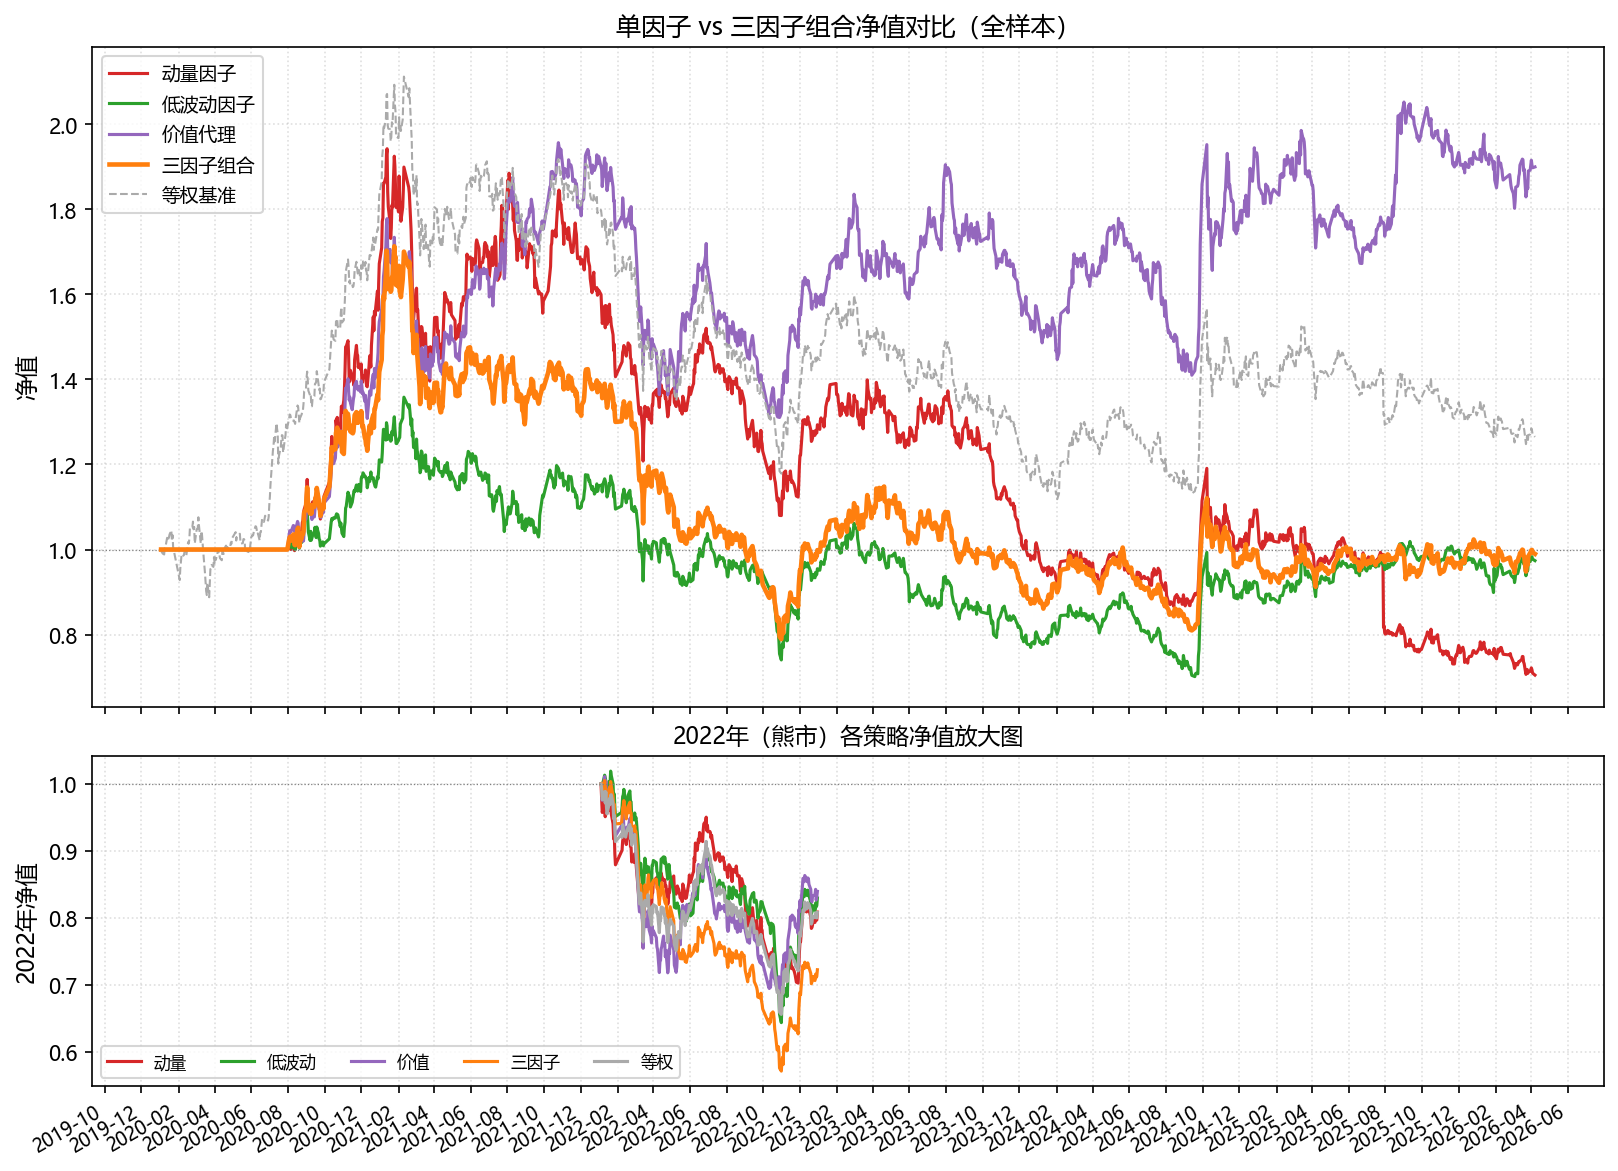

图片已保存：./figs/fig_case_11_factor_decomp.png


In [25]:
# ------------------------------------------------------------------
# 单因子 vs 三因子净值对比
# ------------------------------------------------------------------
def run_single_factor_strategy(factor_col_suffix, names, price_matrix,
                                score_df, simple_ret, nav_idx,
                                top_k=TOP_K, fees=FEES_ONEWAY):
    """运行单因子策略，返回净值序列。factor_col_suffix: 'mom_z'/'vol_z'/'val_z'"""
    score_single = pd.DataFrame({
        name: score_df[f'{name}_{factor_col_suffix}'] for name in names
    })

    wm_single = pd.DataFrame(0.0, index=score_single.index, columns=names)
    for dt in score_single.index:
        top_k_names = score_single.loc[dt].nlargest(top_k).index
        wm_single.loc[dt, top_k_names] = 1.0 / top_k

    # 换手率
    to_single = wm_single.diff().abs().sum(axis=1) / 2
    to_single.iloc[0] = wm_single.iloc[0].sum() / 2

    dw = wm_single.reindex(simple_ret.index, method='ffill').shift(1).fillna(0)
    tc_daily = pd.Series(0.0, index=simple_ret.index)
    for dt in wm_single.index:
        fut = simple_ret.index[simple_ret.index > dt]
        if len(fut) > 0:
            tc_daily[fut[0]] = to_single[dt] * fees * 2
    port_ret = (dw * simple_ret).sum(axis=1) - tc_daily
    return (1 + port_ret).cumprod()

nav_mom = run_single_factor_strategy('mom_z', names, price_matrix, score_df, simple_ret, nav_idx)
nav_vol = run_single_factor_strategy('vol_z', names, price_matrix, score_df, simple_ret, nav_idx)
nav_val = run_single_factor_strategy('val_z', names, price_matrix, score_df, simple_ret, nav_idx)

# 绩效对比
print('=== 单因子 vs 三因子绩效对比 ===')
comp = {
    '动量因子':    calc_metrics(nav_mom, nav_idx),
    '低波动因子':  calc_metrics(nav_vol, nav_idx),
    '价值代理':    calc_metrics(nav_val, nav_idx),
    '三因子组合':  calc_metrics(nav_strat, nav_idx),
    '等权基准':    calc_metrics(nav_ewgt, nav_idx),
}
print_metrics_table({k: {m:v for m,v in d.items() if m in
                          ['年化收益(%)','夏普比率','最大回撤(%)','卡玛比率','信息比率']}
                     for k, d in comp.items()})

# 绘图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9),
                                gridspec_kw={'height_ratios': [2, 1]},
                                sharex=True)
fig.subplots_adjust(hspace=0.1)

ax1.plot(nav_mom,   color='#d62728', lw=1.5, label='动量因子')
ax1.plot(nav_vol,   color='#2ca02c', lw=1.5, label='低波动因子')
ax1.plot(nav_val,   color='#9467bd', lw=1.5, label='价值代理')
ax1.plot(nav_strat, color='#ff7f0e', lw=2.2, label='三因子组合', zorder=4)
ax1.plot(nav_ewgt,  color='#aaa',    lw=1.0, ls='--', label='等权基准')
ax1.axhline(1, color='gray', lw=0.6, ls=':')
ax1.set_ylabel('净值', fontsize=11)
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(linestyle=':', alpha=0.4)
ax1.set_title('单因子 vs 三因子组合净值对比（全样本）', fontsize=12)

# 2022年熊市放大
for nav, label, color in [
    (nav_mom, '动量', '#d62728'), (nav_vol, '低波动', '#2ca02c'),
    (nav_val, '价值', '#9467bd'), (nav_strat, '三因子', '#ff7f0e'),
    (nav_ewgt, '等权', '#aaa'),
]:
    seg = nav['2022-01-01':'2022-12-31']
    seg = seg / seg.iloc[0]
    ax2.plot(seg, color=color, lw=1.5, label=label)

ax2.axhline(1, color='gray', lw=0.6, ls=':')
ax2.set_ylabel('2022年净值', fontsize=11)
ax2.set_title('2022年（熊市）各策略净值放大图', fontsize=11)
ax2.legend(fontsize=8, ncol=5, loc='lower left')
ax2.grid(linestyle=':', alpha=0.4)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30, ha='right', fontsize=9)

plt.savefig('./figs/fig_case_11_factor_decomp.png')
plt.show()
print('图片已保存：./figs/fig_case_11_factor_decomp.png')

## quantstats 完整报告

In [28]:
try:
    import quantstats as qs

    returns_qs = nav_strat.pct_change().dropna()
    bench_qs   = nav_idx.pct_change().dropna()
    common     = returns_qs.index.intersection(bench_qs.index)
    returns_qs = returns_qs[common]
    bench_qs   = bench_qs[common]

    print('=== quantstats 完整绩效指标 ===')
    qs.reports.metrics(returns_qs, benchmark=bench_qs, mode='full')

    qs.reports.html(returns_qs, benchmark=bench_qs,
                    output='case_strategy_report.html',
                    title='A 股三因子选股策略评估报告（2020—2024）')
    print('HTML 报告已保存：./case_strategy_report.html')

    def save_qs_plot(plotter, fname, *args, **kwargs):
        out = f'./figs/{fname}'
        plt.close('all')
        try:
            plotter(*args, show=False, savefig=out, **kwargs)
        except TypeError:
            # 兼容不同 quantstats 版本
            plotter(*args, **kwargs)
            plt.tight_layout()
            plt.savefig(out)
            plt.close()
        print(f'图片已保存：{out}')

    save_qs_plot(
        qs.plots.rolling_sharpe,
        'fig_case_08_rolling_sharpe.png',
        returns_qs, benchmark=bench_qs, period=126
    )

    save_qs_plot(
        qs.plots.drawdowns_periods,
        'fig_case_09_drawdowns.png',
        returns_qs
    )

except ImportError:
    print('quantstats 未安装，请先运行：%pip install quantstats')

=== quantstats 完整绩效指标 ===

Parameter       Value
--------------  ---------
Benchmark       Benchmark
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                           Benchmark    Strategy
-------------------------  -----------  ----------
Start Period               2020-08-03   2020-08-03
End Period                 2026-04-07   2026-04-07
Risk-Free Rate             0.0%         0.0%
Time in Market             100.0%       100.0%

Cumulative Return          -5.42%       -1.03%
CAGR﹪                     -1.02%       -0.19%

Sharpe                     0.03         0.1
Prob. Sharpe Ratio         52.98%       59.69%
Smart Sharpe               0.03         0.1
Sortino                    0.05         0.16
Smart Sortino              0.04         0.15
Sortino/√2                 0.03         0.11
Smart Sortino/√2           0.03         0.11
Omega                      1.01         1.02

Max Drawdown               -45.6%       -53.93%
Max DD Date       

## 全章图片清单

| 文件名 | 对应章节 | 内容 |
|--------|---------|------|
| `fig_case_01_data_quality.png` | §4.1 | 10支股票月度数据覆盖热力图 |
| `fig_case_02_eda.png` | §4.1 | 相关系数热力图 + 累计净值 |
| `fig_case_03_factors.png` | §4.2 | 三因子时序 + 最新截面综合得分 |
| `fig_case_04_holdings.png` | §4.2 | 持仓矩阵 + 月度换手率 |
| `fig_case_05_nav.png` | §4.3 | 策略净值 vs 两基准 + 超额收益 |
| `fig_case_06_walkforward.png` | §4.3 | Walk-Forward OOS 净值 |
| `fig_case_07_monthly_heatmap.png` | §4.3 | 月度收益热力图 |
| `fig_case_08_rolling_sharpe.png` | §4.3 | quantstats 滚动夏普（需安装） |
| `fig_case_09_drawdowns.png` | §4.3 | quantstats 回撤深度（需安装） |
| `fig_case_10_brinson.png` | §4.4 | Brinson 行业归因 |
| `fig_case_11_factor_decomp.png` | §4.4 | 单因子 vs 三因子净值对比 |